In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [6]:
df = pd.read_csv('gurgaon_properties_cleaned_v3.csv')


In [7]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7169.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11498.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,2781.0,NaN,NaN,0,0,0,0,0,0,42


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3671 entries, 0 to 3670
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3671 non-null   object 
 1   society              3671 non-null   object 
 2   sector               3671 non-null   object 
 3   price                3671 non-null   float64
 4   price_per_sqft       3671 non-null   float64
 5   Estimated_area       3671 non-null   float64
 6   areaWithType         3671 non-null   object 
 7   bedRoom              3671 non-null   int64  
 8   bathroom             3671 non-null   int64  
 9   balcony              3671 non-null   object 
 10  floorNum             3655 non-null   float64
 11  facing               3671 non-null   object 
 12  agePossession        3671 non-null   object 
 13  description          3671 non-null   object 
 14  super_built_up_area  1894 non-null   float64
 15  built_up_area        1654 non-null   f

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(3671, 24)

### property_type

<Axes: xlabel='property_type'>

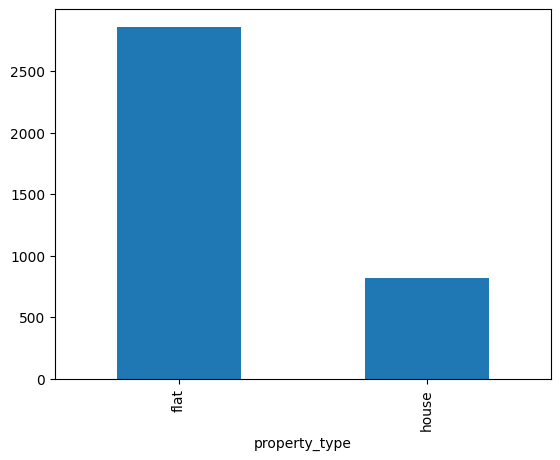

In [12]:
df['property_type'].value_counts().plot(kind='bar')

#### Observations

- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

## society

In [13]:
df['society'].value_counts().shape

(699,)

In [14]:
df['society'].value_counts()

society
independent                             483
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
the nav manesar apartment                 1
ild grand centra                          1
supertech hilltown                        1
aditya apartment                          1
the crew bos chs manesar                  1
Name: count, Length: 699, dtype: int64

In [18]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(75)

society
tulip violet                            0.023526
ss the leaf                             0.046424
dlf new town heights                    0.059598
shapoorji pallonji joyville gurugram    0.072773
signature global park                   0.083752
                                          ...   
dlf the primus                          0.488080
ireo the corridors                      0.491844
mvn athens                              0.495609
central park flower valley              0.499373
emaar mgf marbella                      0.503137
Name: proportion, Length: 75, dtype: float64

In [19]:
society_counts = df['society'].value_counts()

In [20]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(91),
 'Low (2-9)': np.int64(278),
 'Very Low (1)': np.int64(327)}

<Axes: xlabel='society'>

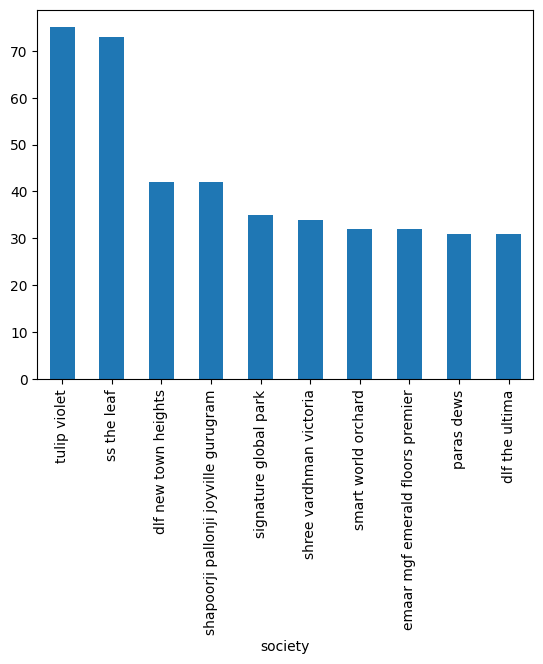

In [21]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [22]:
df['society'].isnull().sum()

np.int64(0)

#### Observations

- Around 13% properties comes under independent tag.
- There are 675 societies. 
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 273 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 308 societies, have only 1 listing.
- 1 missing value

### sector

In [23]:
# unique sectors
df['sector'].value_counts().shape

(117,)

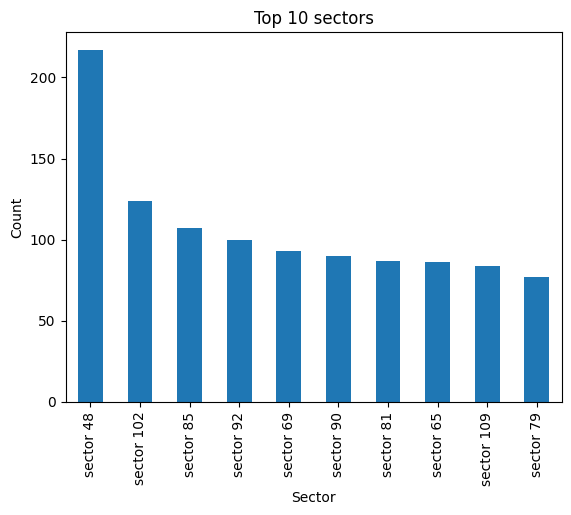

In [28]:
df['sector'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 sectors')
plt.xlabel('Sector')
plt.ylabel('Count')
plt.show()

In [29]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(23),
 'Average (10-49)': np.int64(60),
 'Low (2-9)': np.int64(23),
 'Very Low (1)': np.int64(8)}

#### Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 3 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 16 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

## Price

In [30]:
df['price'].isnull().sum()

np.int64(0)

In [31]:
df['price'].describe()

count    3671.000000
mean        2.422787
std         2.768289
min         0.075000
25%         0.933750
50%         1.500000
75%         2.650000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

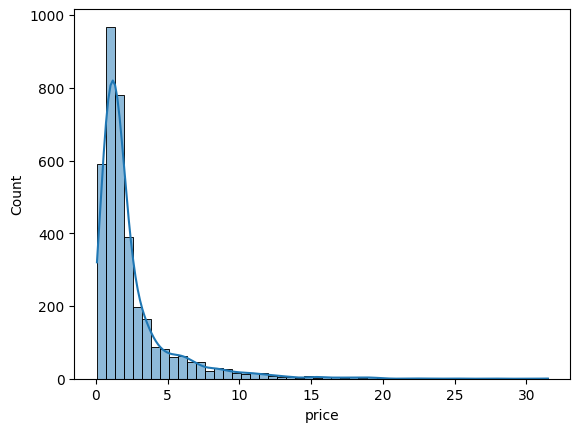

In [32]:
sns.histplot(df['price'], kde=True, bins=50)

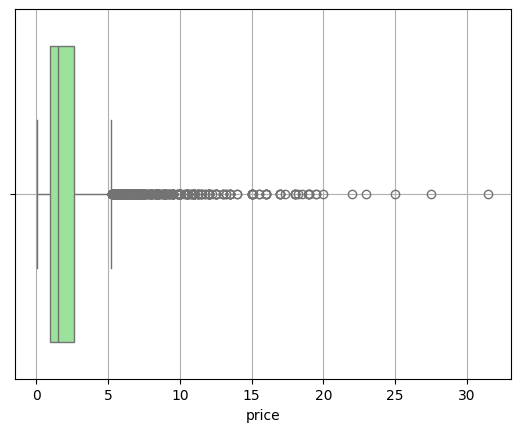

In [33]:
sns.boxplot(x=df['price'], color = 'lightgreen')
plt.grid()

- Descriptive Statistics:

    - Count: There are 3,660 non-missing price entries.
    - Mean Price: The average price is approximately 2.53 crores.
    - Median Price: The median (or 50th percentile) price is 1.52 crores.
    - Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.


- Visualizations:

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
 



In [34]:
# skewness and Kurtosis 
skewness = df['price'].skew()
kurtosis = df['price'].kurtosis()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Skewness: 3.308272598456168
Kurtosis: 15.661257595086337


**Skewness**: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [35]:
# QUALNTILE ANALYSIS 
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])
quantiles

0.01     0.25
0.05     0.37
0.95     8.00
0.99    14.30
Name: price, dtype: float64

Quantile Analysis:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [36]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.7162499999999998)

In [38]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.6406249999999998 5.224375


In [39]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(404, 24)

In [40]:
outliers['price'].describe()

count    404.000000
mean       8.823738
std        3.803970
min        5.250000
25%        6.150000
50%        7.500000
75%       10.000000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

- Based on the IQR method, there are 404 properties considered as outliers.
- These outliers have an average price of approximately 9.24 crores.
- The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

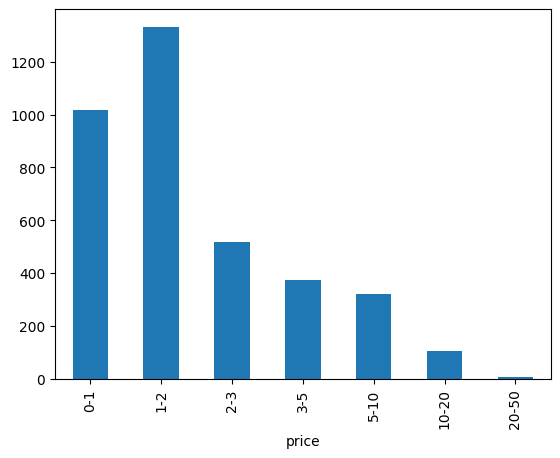

In [41]:
# price binning 
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ['0-1', '1-2', '2-3', '3-5', '5-10', '10-20', '20-50']
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

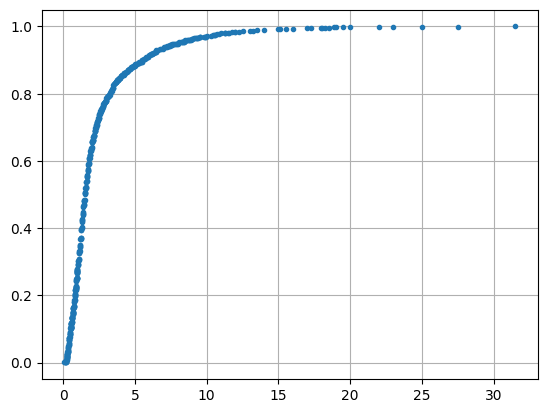

In [ ]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

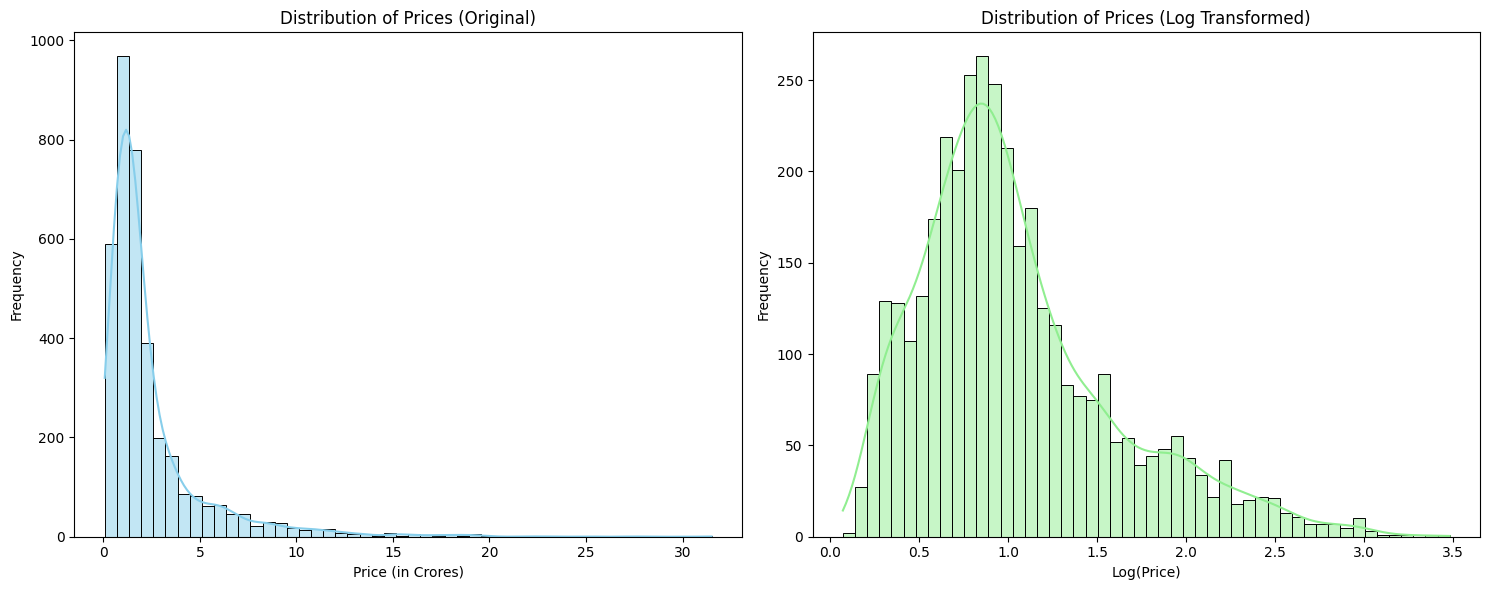

In [44]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. 
It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [45]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0632468950571328 1.018519748957821


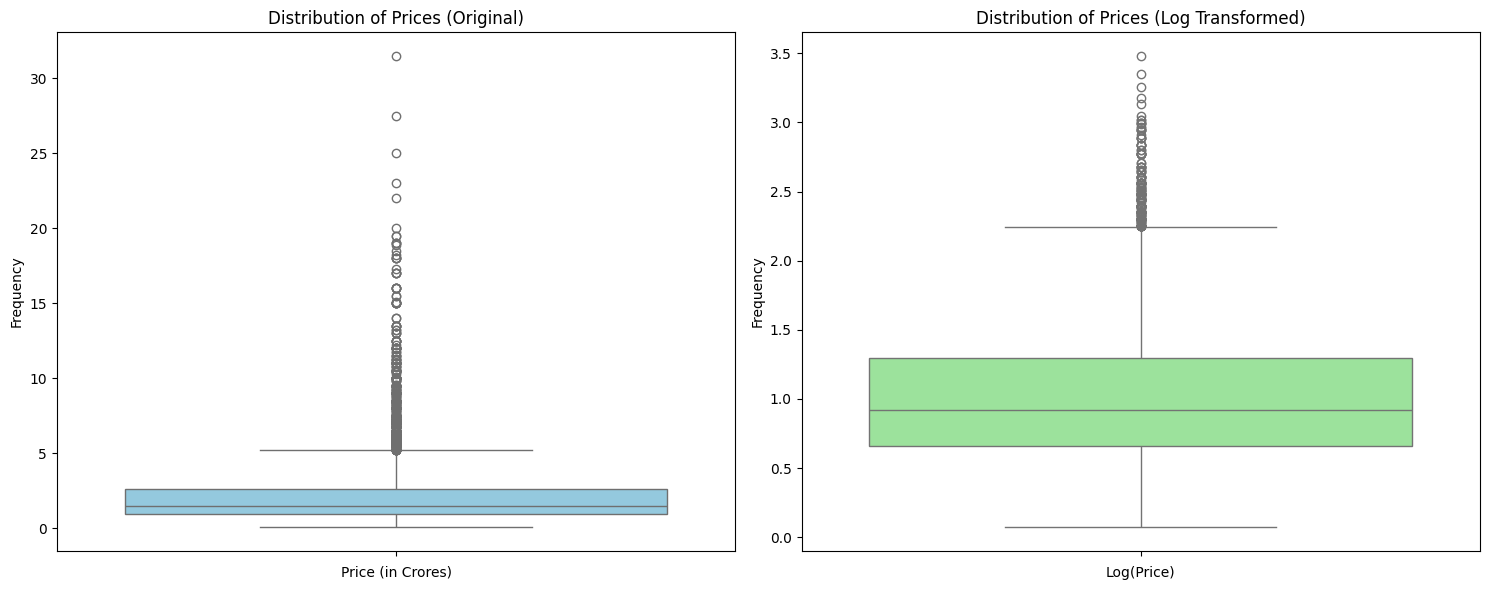

In [46]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### price_per_sqft

In [47]:
df['price_per_sqft'].isnull().sum()

np.int64(0)

In [48]:
df['price_per_sqft'].describe()

count     3671.000000
mean     11184.311087
std       7011.497919
min        544.000000
25%       6709.000000
50%       8855.000000
75%      13111.500000
max      49500.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

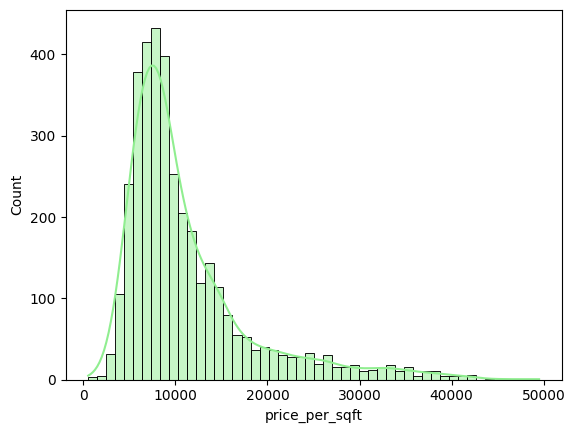

In [49]:
sns.histplot(df['price_per_sqft'], bins=50, color='lightgreen', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

#### Observations

- Potential Outliers
- Right Skewed

<Axes: ylabel='price_per_sqft'>

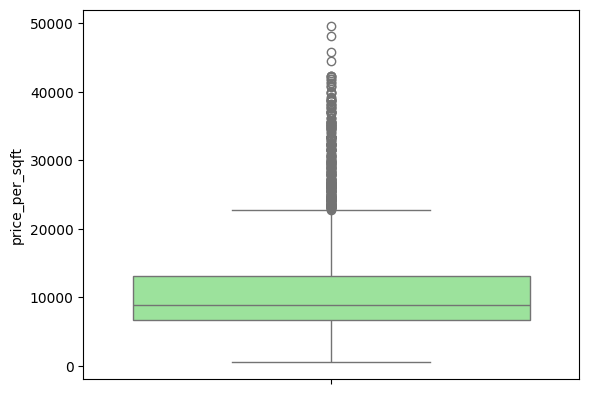

In [50]:
sns.boxplot(df['price_per_sqft'],color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

## bedRoom

In [52]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

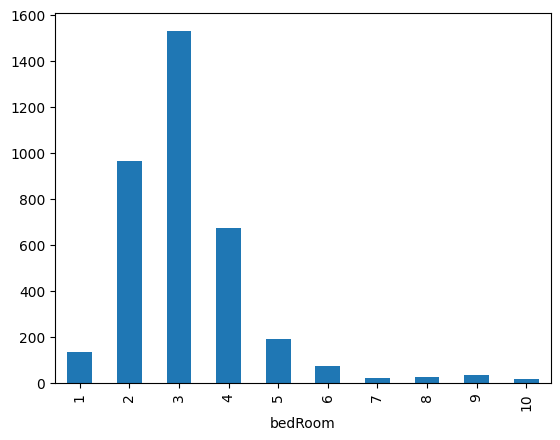

In [53]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

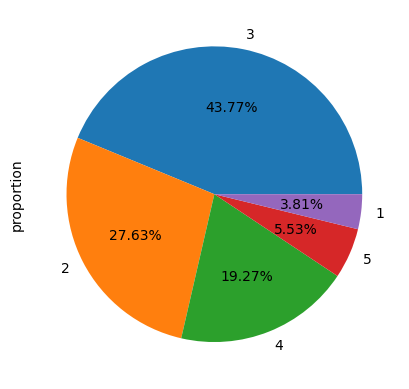

In [54]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

### bathroom

<Axes: xlabel='bathroom'>

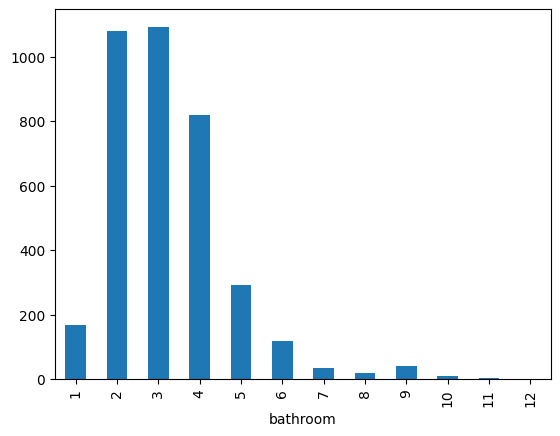

In [55]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

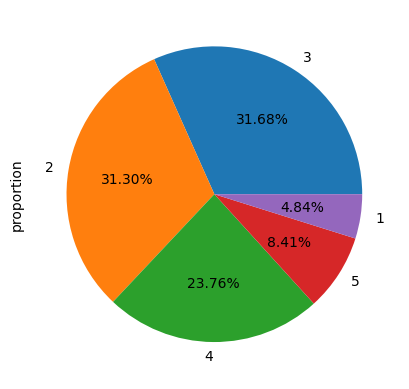

In [56]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [57]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7169.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11498.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,2781.0,NaN,NaN,0,0,0,0,0,0,42


### balcony

In [58]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

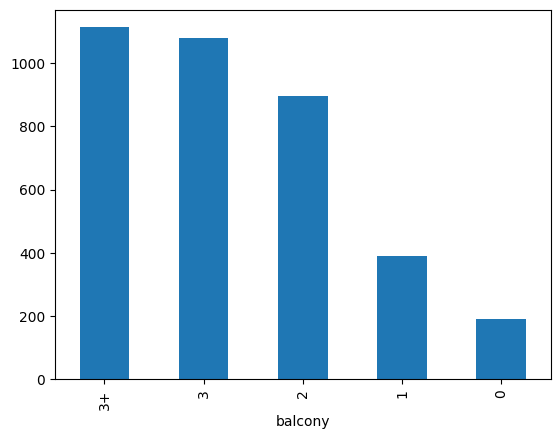

In [59]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

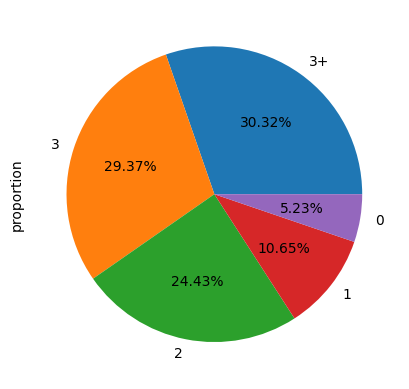

In [60]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

## floorNum


In [61]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,4.0,West,Relatively New,This lovely 2 bhk apartment/flat in sector 85 ...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,4.0,North-East,Old Property,"Sushant lok-3\nBlock-B, corner villa at plot r...",NaN,3438.0,NaN,1,1,1,1,0,0,34
2,2.0,South,New Property,Interested to sell independent house/villa.It ...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,7.0,North-East,New Property,"Right next to the new golf course road, m3m an...",1530.0,NaN,NaN,1,0,0,0,0,0,49
4,2.0,North-East,New Property,Right in heart of gurgaon and delhi is just 2k...,2781.0,NaN,NaN,0,0,0,0,0,0,42


In [62]:
df['floorNum'].isnull().sum()

np.int64(16)

In [63]:
df['floorNum'].describe()

count    3655.000000
mean        6.782216
std         6.068859
min        -1.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

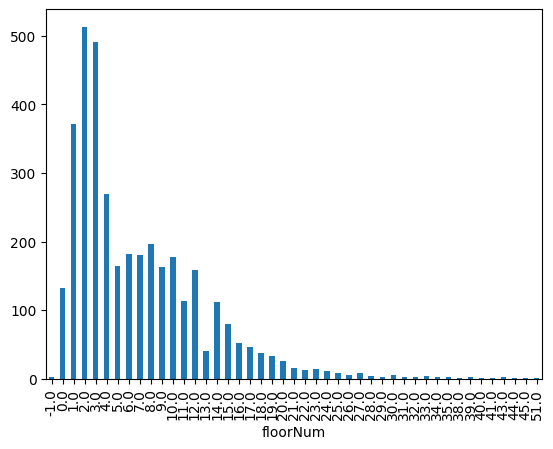

In [64]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='floorNum'>

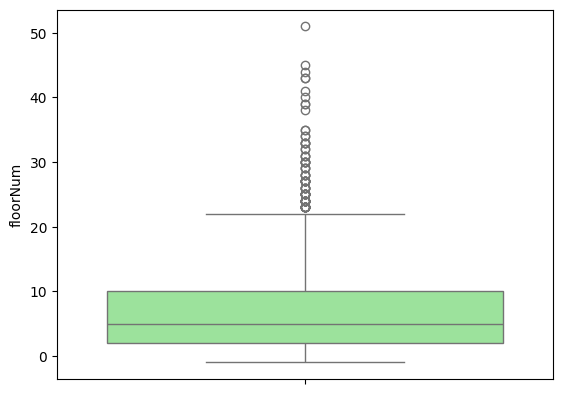

In [65]:
sns.boxplot(df['floorNum'], color='lightgreen')

- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

## facing

In [66]:
df['facing'].isnull().sum()

np.int64(0)

In [67]:
df['facing'].value_counts()

facing
Not Available    1064
North-East        629
East              622
North             379
West              236
South             227
North-West        188
South-East        177
South-West        149
Name: count, dtype: int64

<Axes: xlabel='facing'>

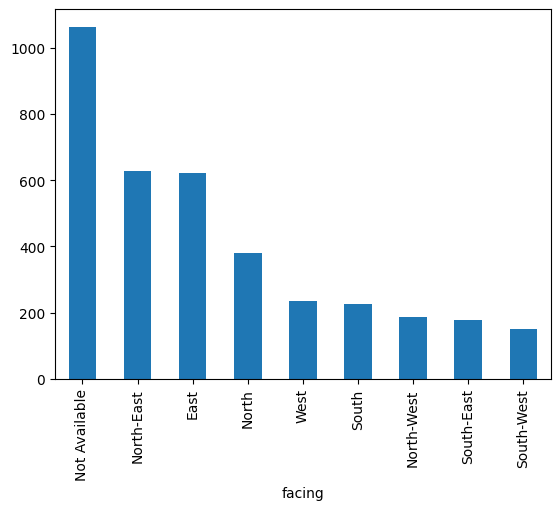

In [68]:
df['facing'].value_counts().plot(kind='bar')

## agePossession

In [69]:
df['agePossession'].isnull().sum()

np.int64(0)

In [70]:
df['agePossession'].value_counts()

agePossession
Relatively New        1626
New Property           702
Moderately Old         562
Undefined              333
Old Property           326
Under Construction     122
Name: count, dtype: int64

<Axes: xlabel='agePossession'>

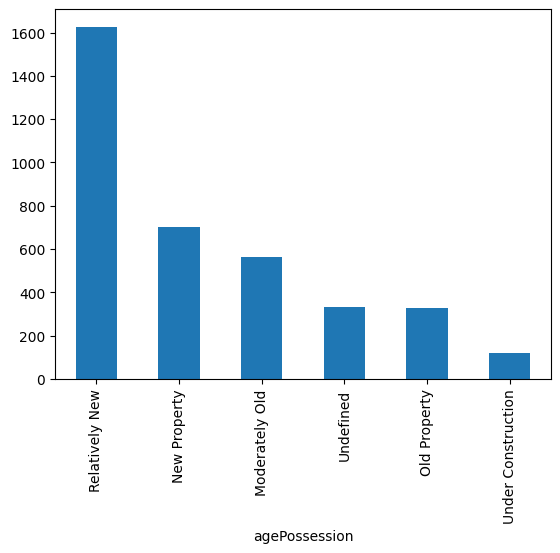

In [71]:
df['agePossession'].value_counts().plot(kind='bar')

## areas

In [72]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1777)

In [73]:
df['super_built_up_area'].describe()

count     1894.000000
mean      1921.049921
std        765.228732
min         89.000000
25%       1466.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

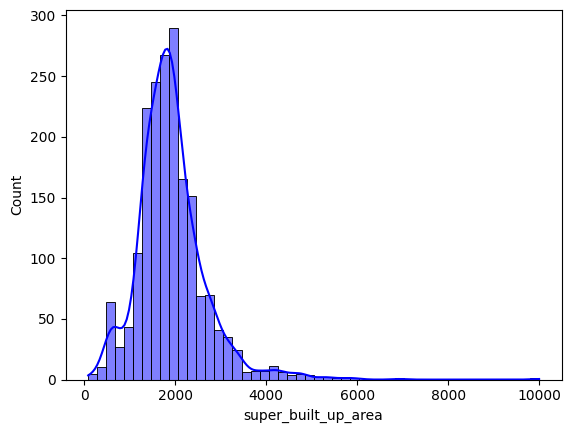

In [75]:
sns.histplot(df['super_built_up_area'].dropna(),kde=True,bins=50,color='blue')

<Axes: ylabel='super_built_up_area'>

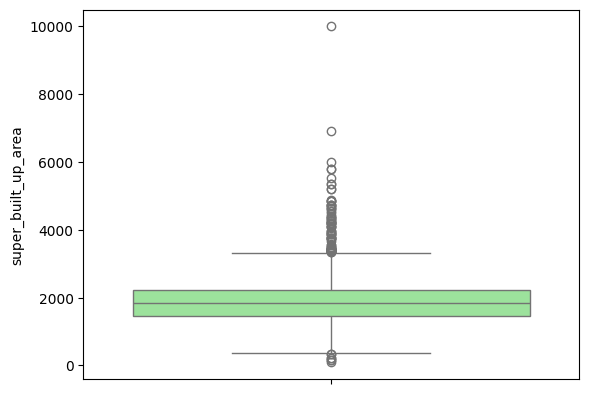

In [76]:
sns.boxplot(df['super_built_up_area'].dropna(),color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

## built up area

In [77]:
df['built_up_area'].isnull().sum()

np.int64(2017)

In [78]:
df['built_up_area'].describe()

count     1654.000000
mean      2003.051215
std       1341.978334
min         54.000000
25%       1200.000000
50%       1708.500000
75%       2430.000000
max      11286.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

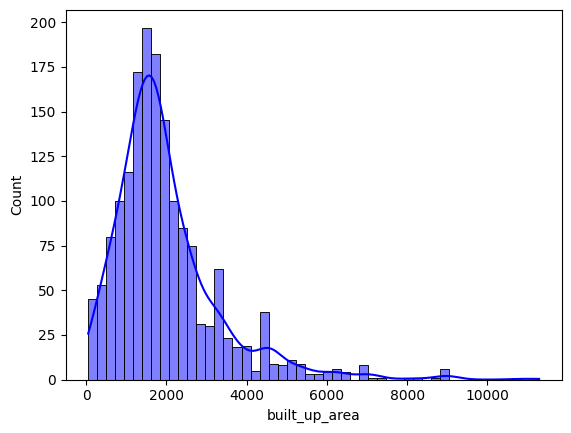

In [80]:
sns.histplot(df['built_up_area'].dropna(),kde=True,bins=50,color='blue' )

<Axes: ylabel='built_up_area'>

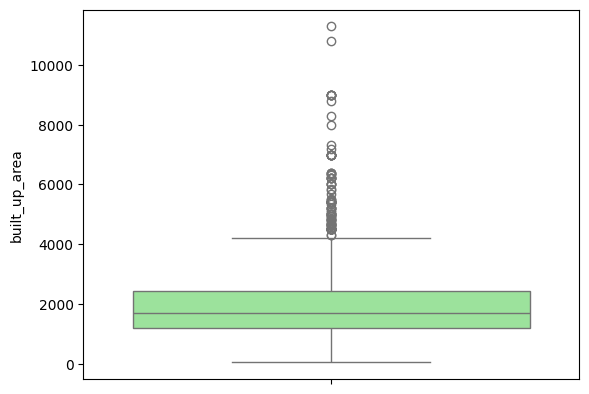

In [81]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.


## carpet area

In [82]:
df['carpet_area'].isnull().sum()

np.int64(1777)

In [83]:
df['carpet_area'].describe()

count     1894.000000
mean      1465.020686
std        937.900987
min         50.000000
25%        900.000000
50%       1320.000000
75%       1800.000000
max      11000.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

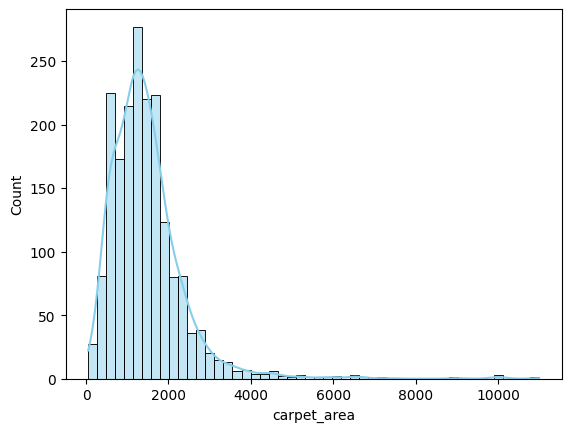

In [85]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='carpet_area'>

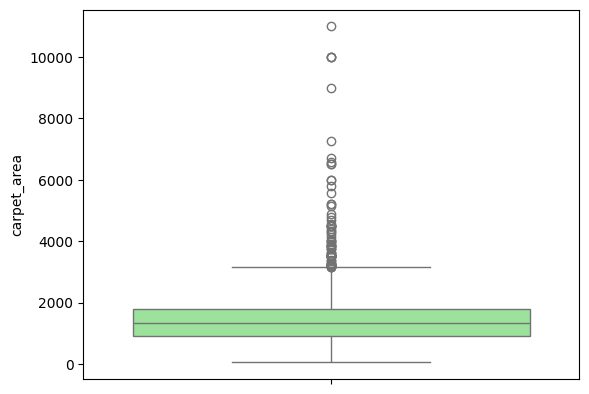

In [86]:
sns.boxplot(df['carpet_area'].dropna(), color='lightgreen')

In [87]:
df.iloc[:,16:]

,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1620.0,0,0,0,0,0,0,49
1,NaN,1,1,1,1,0,0,34
2,NaN,0,0,0,1,0,0,0
3,NaN,1,0,0,0,0,0,49
4,NaN,0,0,0,0,0,0,42
...,...,...,...,...,...,...,...,...
3666,NaN,1,1,1,1,0,2,152
3667,1430.0,1,0,0,0,0,0,174
3668,1290.0,0,0,0,0,0,0,49
3669,1708.0,0,1,0,0,0,1,174


## additional rooms

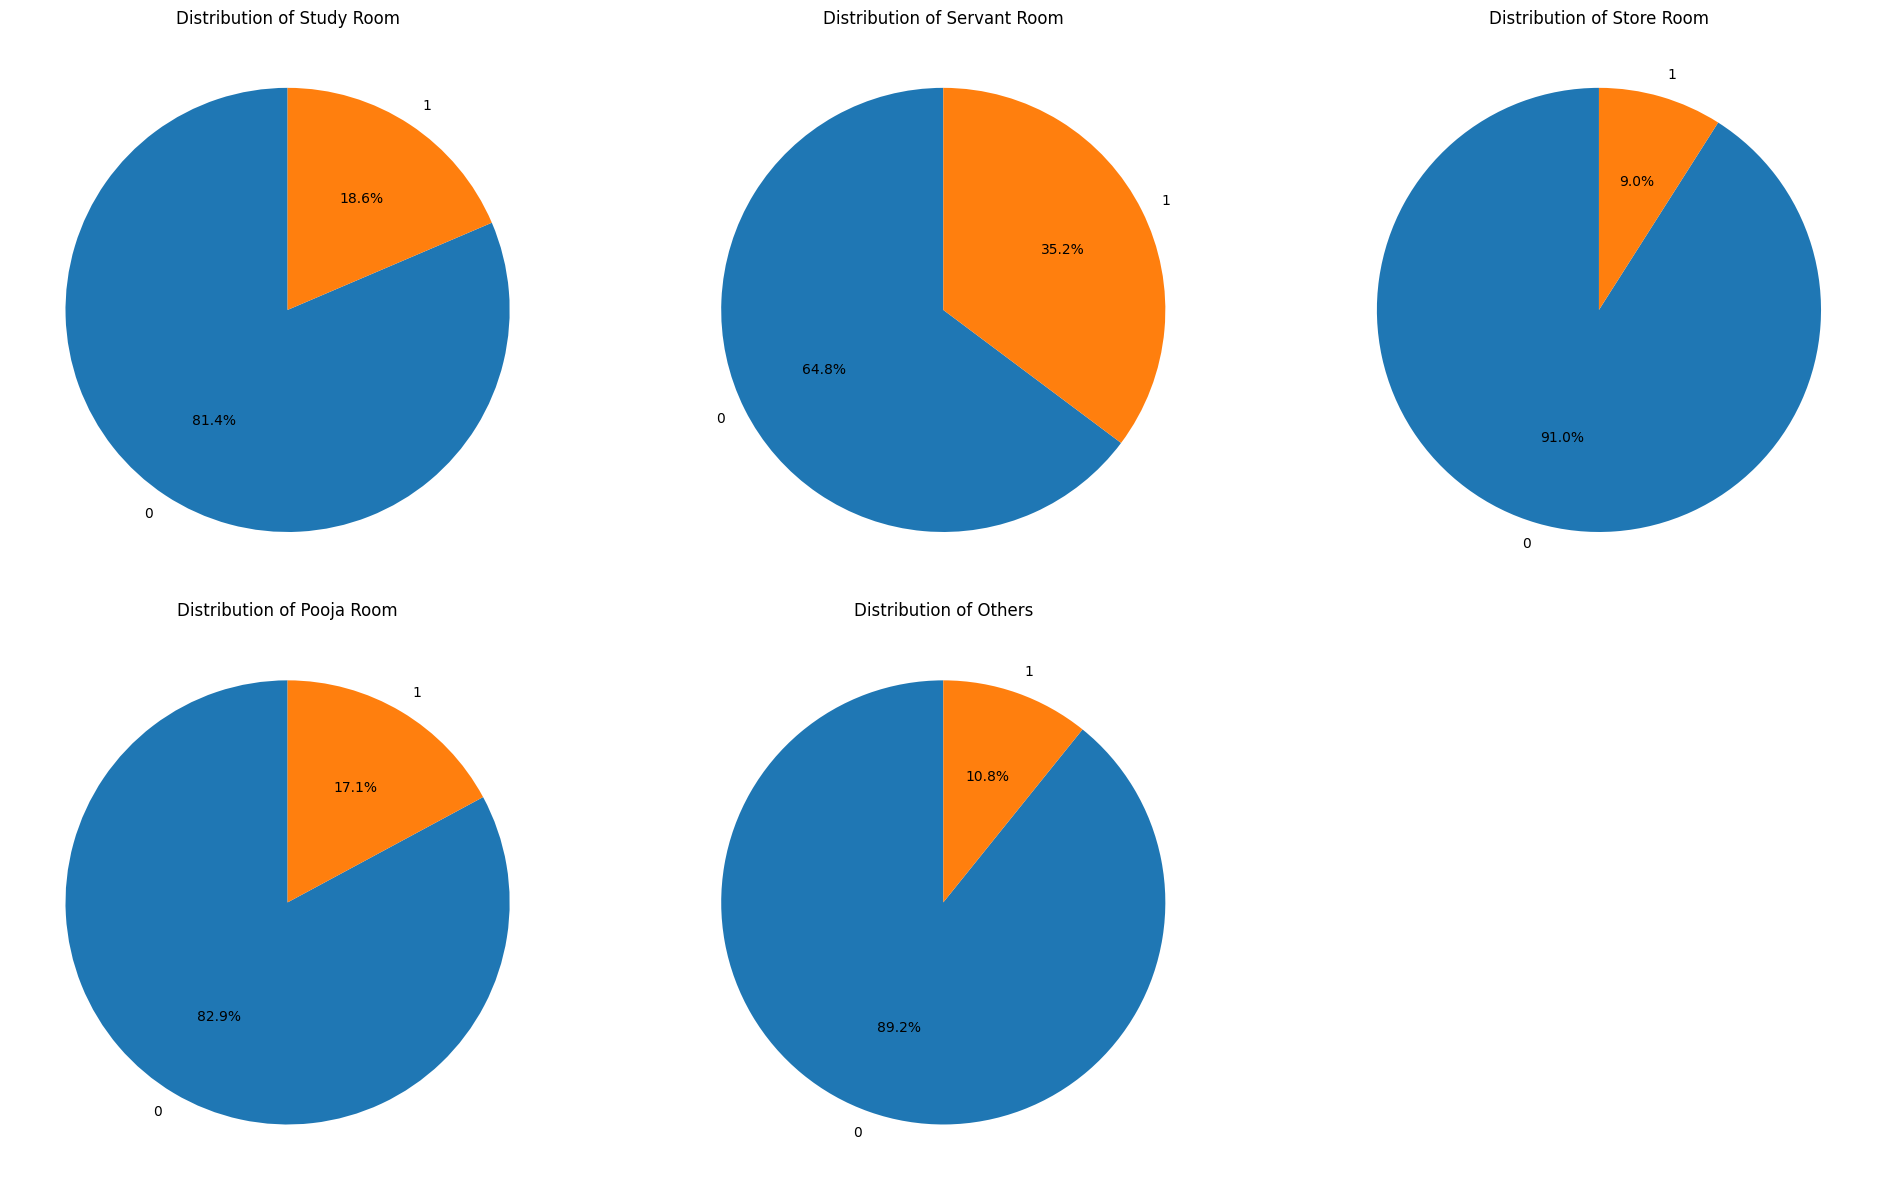

In [89]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

## furnishing_type

In [90]:
df['furnishing_type'].value_counts()

furnishing_type
0    2441
1    1040
2     190
Name: count, dtype: int64

<Axes: ylabel='count'>

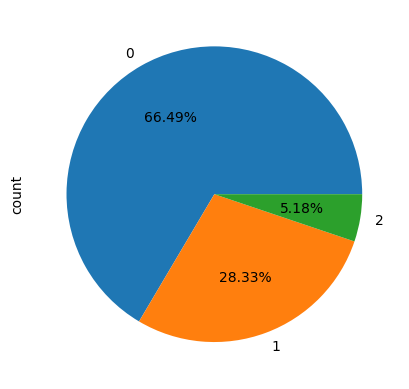

In [91]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

## luxury score

In [92]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [93]:
df['luxury_score'].describe()

count    3671.000000
mean       71.008717
std        53.308551
min         0.000000
25%        31.000000
50%        58.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

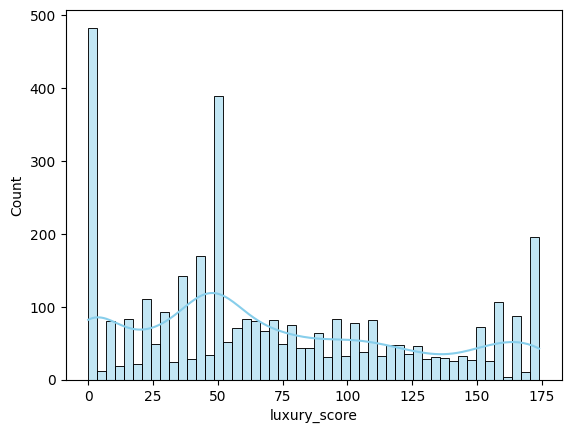

In [94]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='luxury_score'>

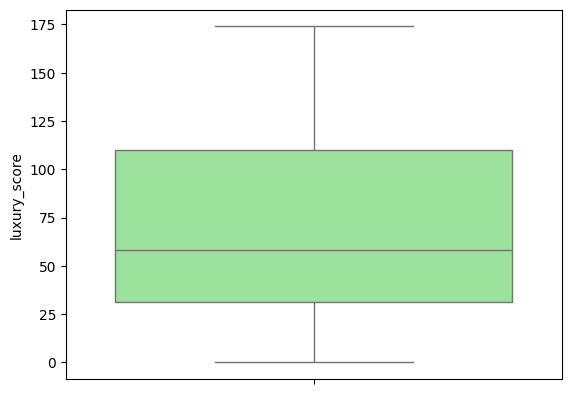

In [95]:
sns.boxplot(df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [96]:
df.head()

,property_type,society,sector,price,price_per_sqft,Estimated_area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,ss,sector 85,1.18,7169.0,1646.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2,2,3,...,1640.0,1630.0,1620.0,0,0,0,0,0,0,49
1,house,independent,sector 57,8.31,24171.0,3438.0,Plot area 382(319.4 sq.m.),5,6,3+,...,NaN,3438.0,NaN,1,1,1,1,0,0,34
2,house,independent,sector 6,1.25,11574.0,1080.0,Plot area 120(100.34 sq.m.)Built Up area: 120 ...,5,5,1,...,NaN,1080.0,NaN,0,0,0,1,0,0,0
3,flat,supertech araville,sector 79,0.95,6209.0,1530.0,Super Built up area 1530(142.14 sq.m.),2,2,3,...,1530.0,NaN,NaN,1,0,0,0,0,0,49
4,flat,ambience creacions,sector 22,3.20,11498.0,2783.0,Super Built up area 2781(258.36 sq.m.),3,4,3+,...,2781.0,NaN,NaN,0,0,0,0,0,0,42
